<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab3/L3_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3.3 IO-Link data collection using JSON interface

## 3.1 Python programming for data collection from IO-Link master

The entire schematic of the data communication using JSON interface using REST API for the IO-Link vibraton device from the IO-Link master is illustrated in Figure 15. As the power meter data collection, your computers (laptop and Raspberry Pi) are on the router network. The IO-Link master is also on the same router network with a static IP address. The ethernet cable (RJ45) is used for connection between the router and the IO-Link master. Note that the IO-Link vibration sensor is connected to the **port 1** of the master. In this case using REST API, each of your computer is not a master but client. The IO-Link master is a server. The data communication sequence to read data from the IO-Link master is summarized as follows.

1.  The computer (Raspberry Pi or laptop) requests data using REST API's post method to the IO-Link master
2.  The IO-Link master read the IO-Link sensor data by the IO-Link protocol
3.  The IO-Link master sends back the received data from the IO-Link sensor to the computer as the JSON format.
4.  The computer receives the JSON data and parse it.

To do this, we will use Python and 'requests' and 'json' packages which are the basic packages in Python. Moreover, refer to details of JSON interface of the IFM IO-Link master [here](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab3/IFM_JSON_Integration_for_IO-Link.pdf?raw=true). The IO-Link vibration sensor (VVB001) manual for interface is also available [here](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab3/IFM_VVB001_IO-Link_Interface_Description.pdf?raw=true). **Please note that this lab manual skips all details to extract data for your convenience. If you perform data collection from other IoT devices, the first thing you have to do is to read the manual and figure out data communication protocols and take appropriate action.**


<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab3_fig15.png?raw=true" width="90%">


*Figure 15 Schematic of communication for IO-Link data collection using JSON interface*

 **The IP address of the gateway at Lab3**.
 <br/>
 Offline class : 192.168.1.102
  <br/>
<font color=”green”> Online class </font> : 10.165.67.146


### Task 3.1

Capture the results of checking network connection using ping test from both Raspberry Pi and laptop to the IO-Link master for REST API as Figure 13 ([Lab3.2](https://githubtocolab.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab3/L3_Colab2.ipynb)) and attach it to the report.
*  Please note that the IP address of the IO-Link master will be different from the example.




---

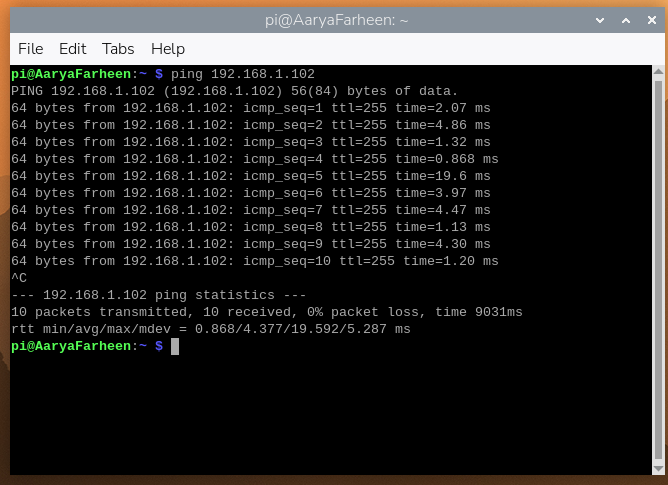

---



If ping test works, you are ready to request data. Before we request data to the IO-Link master, let's see what data is available from the sensor. The selected available data is shown in Table 4. These information is also available on the manual [here](https://github.com/Eunseob/purdue_me597/blob/main/lab/lab3/IFM_VVB001_IO-Link_Interface_Description.pdf?raw=true) on page 9. Other than data from Table 4, tens of more data are available. In this lab, we will collect the selected data only. The refresh rate of the sensor is approximately 200 msec in default setting.

**Note that to take an appropriate value with unit, a multiplier in the Range column of Table 4 must be applied after receiving data. For example, after multiplying 0.0001 to v-Rms value, the measured data has unit of m/s.**

*Table 4 Selected process data from VVB001 sensor*

<table width="100%">
<thead>
  <tr>
    <th>Process data input</th>
    <th>Description</th>
    <th>Record Type</th>
    <th>Range</th>
    <th>Unit</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td>v-Rms</td>
    <td>Speed effective value</td>
    <td rowspan="5">IntegerT (16 bit)</td>
    <td>(0 to 495)*0.0001</td>
    <td>m/s</td>
  </tr>
  <tr>
    <td>a-Peak</td>
    <td>Acceleration peak value</td>
    <td>(0 to 4903)*0.1</td>
    <td>m/s2</td>
  </tr>
  <tr>
    <td>a_Rms</td>
    <td>Acceleration effective value</td>
    <td>(0 to 4903)*0.1</td>
    <td>m/s2</td>
  </tr>
  <tr>
    <td>Temperature</td>
    <td>Current temperature</td>
    <td>(-300 to 800)*0.1</td>
    <td>°C</td>
  </tr>
  <tr>
    <td>Crest</td>
    <td>Acceleration crest factor</td>
    <td>(10 to 500)*0.1</td>
    <td>-</td>
  </tr>
</tbody>
</table>

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_Python.png?raw=tru" width="20">Python - Python 3 ([lab3_sample2.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab3/lab3_sample2.py?raw=true))**

```
import requests
import json
import datetime

# define the IO-Link master IP
URL = "http://192.168.1.102/" # For online student with Cisco VPN : 10.165.67.146

# define JSON body for post method
# for the details, see the JSON interface manual
# note that the sensor is connected to port 1
BODY = {
        "code":"request",
        "cid":-1,
        "adr":"/iolinkmaster/port[1]/iolinkdevice/iolreadacyclic",
        "data":{"index":40,"subindex":0}    
}

now = datetime.datetime.now()

# this requests data to the IO-Link master
# using POST method of REST API with BODY information
# req object will be response from the IO-Link master
req = requests.post(url = URL, json=BODY)

data_json = req.json() # this is json format data of req

# because the the JSON data itself is in unformatted,
# dumps method of JSON module below helps us to see the data in JSON format
data_json_formatted = json.dumps(data_json, indent=2)

print(now, ': Data structure from the IO-Link master\n',data_json_formatted)

# parsing JSON:
# as you can see the above print,
# 'value' is accesible in 'data' of the JSON data
value = data_json['data']['value']

# the raw measured value looks like 0000FC000002FF000000FF0000F6FF000026FF03
# the length of the value is 40
# this is byte array in 16-bit integer format
print('raw measured value is', value)


# Always, the returned value type from JSON is string
# below is converting the value to v-Rms
# description of v_rms variable is that
# first, select first four elements from value
# second, convert them into 16-bit integer
# third, multiply 0.0001 to take the correct unit (m/s) and data
# finally, rounding up and the data type is float
v_rms = round(int(value[0:4], 16) * 0.0001)

print('v_Rms =', v_rms ,'m/s')

### indexing information is that
# a_Peak data = value[8:12]
# a_Rms data = value[16:20]
# Temperature data = value[24:28]
# Crest data = value[32:36]

```

---

The sample code 2 (lab3_sample2.py) is given as above. This code is to print out v_Rms. Go through the code and run it. Based on the given code, perform the Tasks below.

### Task 3.2

Modify the sample code 2 on both laptop and Raspberry Pi to print out all data (v_Rms, a_Peak, a_Rms, Temperature, and Crest) as Table 4.

* Print the values with units in Table 4




---

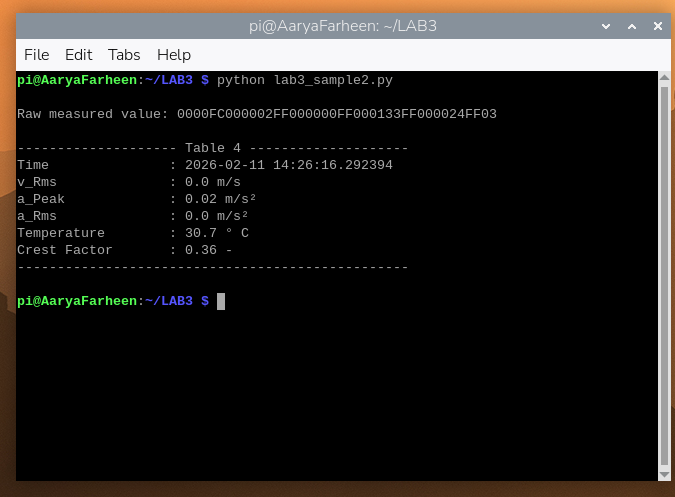

---



### Task 3.3

1.	Perform the same as Task 2.3; Modify sample code 2 to collect IO-Link data for at least 1 minute and save data as a CSV file.

* You can use one computer either laptop or Raspberry Pi.
* Set the sampling period 1 second.
* Data (header) should include time or datetime, v_Rms, a_Peak, a_Rms, Temperature, Crest as Table 5.
* As a practice, plot data and calculate time-domain features.

*Table 5 Example data of output CSV file for Task 3.3*
<table width="100%">
<thead>
  <tr>
    <th>Time [sec]</th>
    <th>v_Rms [m/s]</th>
    <th>a_Peak [m/s2]</th>
    <th>a_Rms [m/s2]</th>
    <th>Temperature [C]</th>
    <th>Crest [-]</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td colspan="6" align="center">...</td>
  </tr>
  <tr>
    <td>10.254</td>
    <td>0.001</td>
    <td>1.24</td>
    <td>0.48</td>
    <td>24.1</td>
    <td>2.58</td>
  </tr>
  <tr>
    <td>10.461</td>
    <td>0.002</td>
    <td>1.34</td>
    <td>0.51</td>
    <td>23.9</td>
    <td>2.63</td>
  </tr>
  <tr>
    <td colspan="6" align="center">...</td>
  </tr>
</tbody>
</table>

In [ ]:
### Place your entire code for Task 3.3 Here
# If you want, you can add more code block below to load csv file and plot it.

# -*- coding: utf-8 -*-
import requests
import json
import datetime
import time
import csv
import numpy as np
import matplotlib.pyplot as plt



# -------------------------------

# IO-Link Master Configuration

# -------------------------------
URL = "http://192.168.1.102/"  # Change if needed

BODY = {
    "code": "request",
    "cid": -1,
    "adr": "/iolinkmaster/port[1]/iolinkdevice/iolreadacyclic",
    "data": {"index": 40, "subindex": 0}
}



# -------------------------------

# Data Storage

# -------------------------------
time_list = []
vRms_list = []
aPeak_list = []
aRms_list = []
Temp_list = []
Crest_list = []

# -------------------------------

# Data Collection Parameters

# -------------------------------

duration = 60  # seconds
sampling_period = 1  # second
start_time = time.time()
print("Starting 1-minute IO-Link data collection...")



while (time.time() - start_time) < duration:
    elapsed_time = int(time.time() - start_time)
    try:
        # Send POST request
        req = requests.post(url=URL, json=BODY, timeout=2)
        data_json = req.json()
        # Extract raw value
        value = data_json['data']['value']

        # -------------------------------

        # Convert raw values

        # -------------------------------
        v_Rms      = round(int(value[0:4], 16) * 0.0001, 4)
        a_Peak     = round(int(value[8:12], 16) * 0.01, 2)
        a_Rms      = round(int(value[16:20], 16) * 0.01, 2)
        Temperature= round(int(value[24:28], 16) * 0.1, 1)
        Crest      = round(int(value[32:36], 16) * 0.01, 2)

        # -------------------------------

                # Store values

        # -------------------------------
        time_list.append(elapsed_time)
        vRms_list.append(v_Rms)
        aPeak_list.append(a_Peak)
        aRms_list.append(a_Rms)
        Temp_list.append(Temperature)
        Crest_list.append(Crest)



        # Print Table 5 format (Unicode-safe)

        print(f"Time:{elapsed_time}s | v_Rms:{v_Rms} m/s | a_Peak:{a_Peak} m/s\u00B2 | a_Rms:{a_Rms} m/s\u00B2 | Temp:{Temperature} \u00B0C | Crest:{Crest} -")



    except Exception as e:

        print(f"Error at t={elapsed_time}s: {e}")
    time.sleep(sampling_period)

print("Data collection completed.")

# -------------------------------

# Save to CSV (Table 5 format)

# -------------------------------
csv_file = "iolink_data_table5.csv"
with open(csv_file, mode="w", newline="") as file:
    writer = csv.writer(file)

    # Table 5 header
    writer.writerow(["Time [sec]", "v_Rms [m/s]", "a_Peak [m/s\u00B2]", "a_Rms [m/s\u00B2]", "Temperature [\u00B0C]", "Crest [-]"])
    for i in range(len(time_list)):
        writer.writerow([
            time_list[i],
            vRms_list[i],
            aPeak_list[i],
            aRms_list[i],
            Temp_list[i],
            Crest_list[i]
        ])

print(f"CSV file saved as '{csv_file}'")


# -------------------------------

# Convert lists to NumPy arrays for analysis

# -------------------------------

vRms_arr  = np.array(vRms_list)
aPeak_arr = np.array(aPeak_list)
aRms_arr  = np.array(aRms_list)
Temp_arr  = np.array(Temp_list)
Crest_arr = np.array(Crest_list)

# -------------------------------

# Time-Domain Features

# -------------------------------

print("\n----- Time-Domain Features -----")

def calc_features(arr, name, unit=""):
    print(f"{name} Mean: {np.mean(arr):.3f} {unit}")
    print(f"{name} RMS : {np.sqrt(np.mean(arr**2)):.3f} {unit}")
    print(f"{name} Std : {np.std(arr):.3f} {unit}")
    print("-"*40)

calc_features(vRms_arr, "v_Rms", "m/s")
calc_features(aPeak_arr, "a_Peak", "m/s\u00B2")
calc_features(aRms_arr, "a_Rms", "m/s\u00B2")
calc_features(Temp_arr, "Temperature", "\u00B0C")
calc_features(Crest_arr, "Crest Factor", "-")

# -------------------------------

# Plot Data

# -------------------------------

plt.figure()
plt.plot(time_list, vRms_arr, marker='o')
plt.title("v_Rms vs Time")
plt.xlabel("Time [sec]")
plt.ylabel("v_Rms [m/s]")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(time_list, aPeak_arr, marker='o', label='a_Peak')
plt.plot(time_list, aRms_arr, marker='x', label='a_Rms')
plt.title("Acceleration vs Time")
plt.xlabel("Time [sec]")
plt.ylabel("Acceleration [m/s\u00B2]")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(time_list, Temp_arr, marker='o', color='red')
plt.title("Temperature vs Time")
plt.xlabel("Time [sec]")
plt.ylabel("Temperature [\u00B0C]")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(time_list, Crest_arr, marker='o', color='purple')
plt.title("Crest Factor vs Time")
plt.xlabel("Time [sec]")
plt.ylabel("Crest [-]")
plt.grid(True)
plt.show()

## 3.2 Data collection from multiple sensors in a single program

In this lab so far, we collected data from each sensor in a program. In this section, we try to collect data from both sensors at the same time in a single program.

Perform the Tasks below.

### Task 3.4

By using the sample code 1 and 2, program a Python code as instructed below.

* Make infinitely printing out all sensor data at the same time in a 'while' loop.
* Use 'try' and 'except' to halt your program when pressing Ctrl+c.
* Capture your console window or terminal when your program is running and attach it below.
* You can use either laptop or Raspberry Pi to run this code.




---

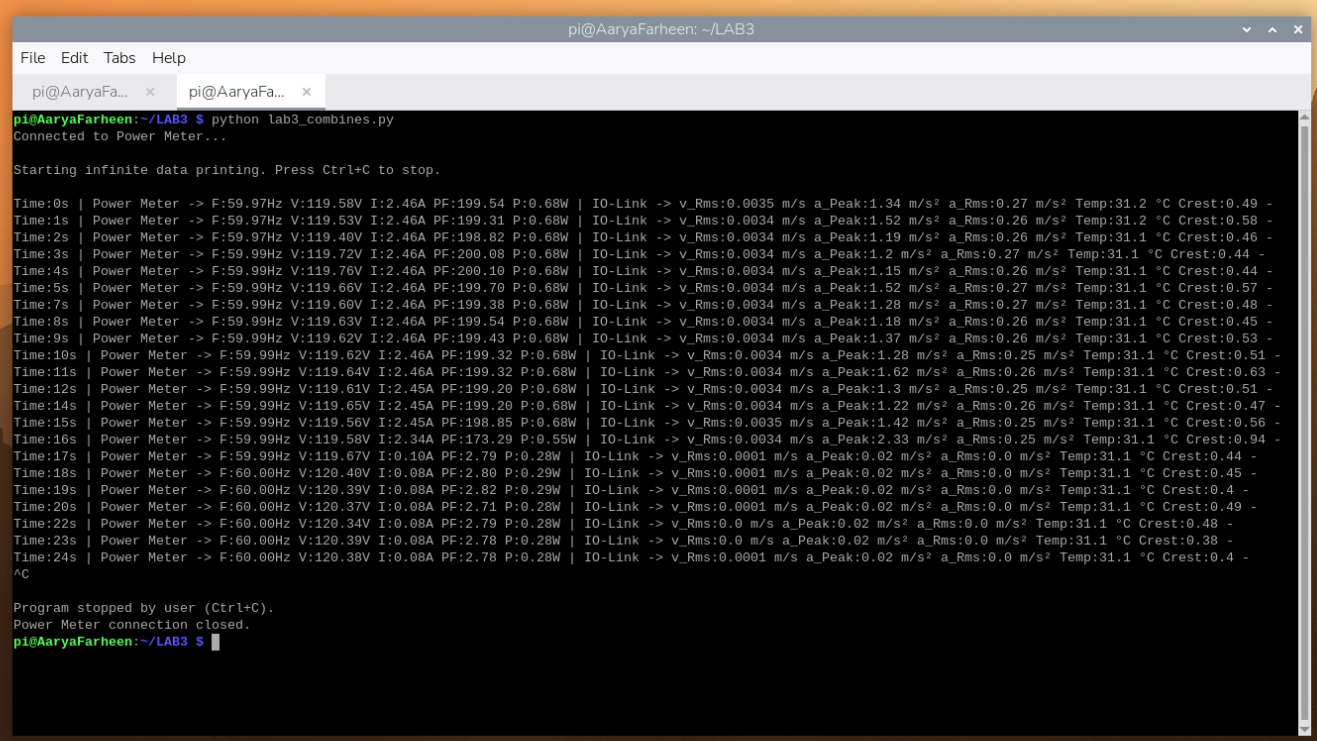

---



In [ ]:
### place your code for Task 3.4
# -*- coding: utf-8 -*-
from pymodbus.client.sync import ModbusTcpClient
from pymodbus.constants import Endian
from pymodbus.payload import BinaryPayloadDecoder
import requests
import json
import time
import datetime

# -------------------------------
# Power Meter Configuration
# -------------------------------
def registers_to_float(registers):
    decoder = BinaryPayloadDecoder.fromRegisters(
        registers,
        byteorder=Endian.Big,
        wordorder=Endian.Big
    )
    return decoder.decode_32bit_float()

pm_host = "192.168.1.100"  # Power meter IP
pm_port = 502
pm_unit_id = 1

pm_client = ModbusTcpClient(pm_host, port=pm_port)
if not pm_client.connect():
    raise RuntimeError(f"Cannot connect to Power Meter: {pm_host}:{pm_port}")
print("Connected to Power Meter...")

# -------------------------------
# IO-Link Configuration
# -------------------------------
iolink_URL = "http://192.168.1.102/"  # IO-Link Master IP
iolink_BODY = {
    "code": "request",
    "cid": -1,
    "adr": "/iolinkmaster/port[1]/iolinkdevice/iolreadacyclic",
    "data": {"index": 40, "subindex": 0}
}

# -------------------------------
# Infinite Data Collection
# -------------------------------
try:
    print("\nStarting infinite data printing. Press Ctrl+C to stop.\n")
    start_time = time.time()
    while True:
        elapsed_time = int(time.time() - start_time)

        # ----- Power Meter Data -----
        freq_read  = pm_client.read_holding_registers(1536, 2, unit=pm_unit_id)
        volt_read  = pm_client.read_holding_registers(1538, 2, unit=pm_unit_id)
        curr_read  = pm_client.read_holding_registers(1550, 2, unit=pm_unit_id)
        pf_read    = pm_client.read_holding_registers(1564, 2, unit=pm_unit_id)
        power_read = pm_client.read_holding_registers(1582, 2, unit=pm_unit_id)

        if not freq_read.isError():
            F  = registers_to_float(freq_read.registers)
            V  = registers_to_float(volt_read.registers)
            I  = registers_to_float(curr_read.registers)
            PF = registers_to_float(pf_read.registers)
            P  = registers_to_float(power_read.registers)
        else:
            F = V = I = PF = P = float('nan')

        # ----- IO-Link Data -----
        try:
            req = requests.post(url=iolink_URL, json=iolink_BODY, timeout=2)
            data_json = req.json()
            value = data_json['data']['value']

            v_Rms       = round(int(value[0:4], 16) * 0.0001, 4)
            a_Peak      = round(int(value[8:12], 16) * 0.01, 2)
            a_Rms       = round(int(value[16:20], 16) * 0.01, 2)
            Temperature = round(int(value[24:28], 16) * 0.1, 1)
            Crest       = round(int(value[32:36], 16) * 0.01, 2)
        except Exception:
            v_Rms = a_Peak = a_Rms = Temperature = Crest = float('nan')

        # ----- Print All Data -----
        print(f"Time:{elapsed_time}s | "
              f"Power Meter -> F:{F:.2f}Hz V:{V:.2f}V I:{I:.2f}A PF:{PF:.2f} P:{P:.2f}W | "
              f"IO-Link -> v_Rms:{v_Rms} m/s a_Peak:{a_Peak} m/s\u00B2 a_Rms:{a_Rms} m/s\u00B2 Temp:{Temperature} \u00B0C Crest:{Crest} -")

        time.sleep(1)

except KeyboardInterrupt:
    print("\n\nProgram stopped by user (Ctrl+C).")
finally:
    pm_client.close()
    print("Power Meter connection closed.")


### Task 3.5

Let's think more about IoT sensors and data collection in the sense of the programmer. The answers are open-ended. Answer the questions below.

#### 1) If you want to collect data from muliple sensors which have different sampling periods, how can you implement your program?



---

If multiple IoT sensors have different sampling periods, you can implement the program in these simple ways:

1️⃣ Multi-threading
Create a separate thread/task for each sensor. Each thread reads data and sleeps based on its sampling time.

2️⃣ Timer-based scheduling (Single loop)
Use one main loop and check timestamps. If the required time has passed, read that sensor.

3️⃣ Asynchronous programming
Use an event loop (async/await) to schedule sensor readings at different intervals.

---



#### 2) How can you make your program robust/stable even if suddenly unwanted network connection failure happens?





---

To make your IoT program robust and stable during sudden network failures, you can:

1️⃣ Use Exception Handling
Wrap network code in try–except blocks to prevent crashes.

2️⃣ Auto Reconnection Logic
Implement automatic retry with delay (exponential backoff).

3️⃣ Local Buffering
Store data locally (queue/file/database) when network is down and send it once reconnected.

4️⃣ Timeout Handling
Set proper connection and response timeouts to avoid hanging.

5️⃣ Heartbeat / Connection Monitoring
Periodically check connection status.

6️⃣ Fail-Safe Mode
Ensure sensors continue collecting data even if transmission fails

---



#### 3) What can you do with the electrical power and vibration data? Can they be used for an operational condition or health monitoring?



---

Yes, electrical power and vibration data are widely used for operational and health monitoring.

Operational monitoring:

Detect ON/OFF state

Identify load levels

Monitor energy usage

Health monitoring:

Vibration → detect imbalance, misalignment, bearing faults

Power data → detect overcurrent, motor faults, electrical issues

They help in fault detection, condition monitoring, and predictive maintenance to prevent breakdowns.

---



## Lab3 Summary and Deliverables

Answer the following questions for your achievements




### Q1. Please summarize Lab3.

---

Collect real-time data from a power meter (Modbus TCP) and an IO-Link vibration sensor.

Understand communication protocols, data conversion, and time-domain analysis.

Save data to CSV and visualize trends.

---


### Q2. What skills did you have to develop to accomplish this project?

---
Writing scripts to communicate with hardware devices.

Using modules like pymodbus, requests, json, csv, time, numpy, and matplotlib.

Handling infinite loops with while True and safely stopping programs using try / except KeyboardInterrupt.

Converting hexadecimal and register data to meaningful float values.

---

### Q3. What aspects of this project were the most beneficial for your learning?

---

This project provided practical experience in real-time monitoring, sensor integration, and data analysis, which is directly applicable to industrial automation, IoT, and smart systems.

---

### Q4. What challenges did you encounter in completing the project?

---

Unicode handling: Displaying units like °C and m/s² without errors in Python.

Synchronization: Collecting and printing data from multiple sensors simultaneously.

Infinite loop handling: Ensuring the program could stop safely with Ctrl+C.

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

Used try/except and timeouts for communication errors.

Converted Modbus and IO-Link data correctly to floats.

Declared UTF-8 and used Unicode for units.

Synchronized sensor reads in one loop.

Handled safe exit with KeyboardInterrupt.

---

<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)